In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path
sys.path.append('/lab/barcheese01/smaffa/coTISja/src')

from scripts.plotting import *
from scripts.filter_utils import *
from scripts.analysis_pipelines import *
import statsmodels
import re

pd.set_option('display.max_columns', None)

In [47]:
experiment_table, _, replicate_df = load_experiment_manifest()
tis_type_frequency_order = ['Annotated', 'Truncated', 'Extended', 'uORF', 'Other']
tis_type_positional_order = ['uORF', 'Extended', 'Annotated', 'Truncated', 'Other']
codon_order = ['ATG', 'ATA', 'ATC', 'ATT', 'ACG', 'AAG', 'AGG', 'GTG', 'TTG', 'CTG']
sample_order = ['HeLa', 'K562', 'RPE1_Async', 'RPE1_Que', 'RPE1_Sen', 'U2OS']
cell_lines = ['HeLa', 'K562', 'RPE1_Async', 'U2OS']
rpe1_states = ['RPE1_Async', 'RPE1_Que', 'RPE1_Sen']

In [140]:
all_replicate_tis_df = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/filtered_tis_data/per_rep/all_samples_filtered_with_protein_seq.csv')
all_replicate_tis_df = all_replicate_tis_df.assign(
    IsoformID=all_replicate_tis_df['Tid'] + ':' + all_replicate_tis_df['Start'].astype(int).astype(str),
    TIS_ID=all_replicate_tis_df['Gid'] + ':' + all_replicate_tis_df['GenomeStart'],
    TIS=all_replicate_tis_df.apply(lambda x: f'{x["Tid"]}_{int(x["Start"])}_{x["GenomeStart"]}:{x["GenomePos"].split(":")[-1]}', axis=1)
)
tis_metadata = all_replicate_tis_df[
    ['TIS', 'Tid', 'Symbol', 'Gid', 'GeneType', 'GenomeStart', 'StartCodon', 'Start', 'RecatTISType', 'MANE_Select', 'AALen', 'AASeq']
].sort_values(by='AASeq').drop_duplicates(
    ['TIS']
)

In [141]:
all_replicate_tis_df = calculate_normalization_factors(
    all_replicate_tis_df, 
    id_columns = ['Sample', 'Replicate'],
    reference_sample = ('HeLa', 'rep1'),
    experiment_table=replicate_df[replicate_df['condition'] == 'TIS'].assign(rnaseq_count_file=lambda x: x['rnaseq_count_file'].apply(lambda y: [y])),
    id_cols = ['sample', 'replicate']
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log

In [68]:
paired_isoform_df = pair_canonical_isoforms(
    all_replicate_tis_df, 
    id_columns=['Sample', 'Replicate', 'Tid']
)

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# use first upstream codon to evaluate codon identity strength (whether or not we can group all non-AUG together or not)

In [69]:
all_replicate_tis_df.value_counts('RecatTISType')

RecatTISType
Annotated    179408
Truncated    105436
Other         69463
Extended      44415
uORF          31404
Name: count, dtype: int64

In [70]:
first_codon_tis_ids = all_replicate_tis_df[
    (~all_replicate_tis_df['Imputed']) # &
    # (all_replicate_tis_df['MANE_Select'])
].sort_values(['Tid', 'Start']).drop_duplicates(subset=['Tid'])['TIS_ID'].tolist()

Text(0.5, 1.0, 'First detected TIS along transcript')

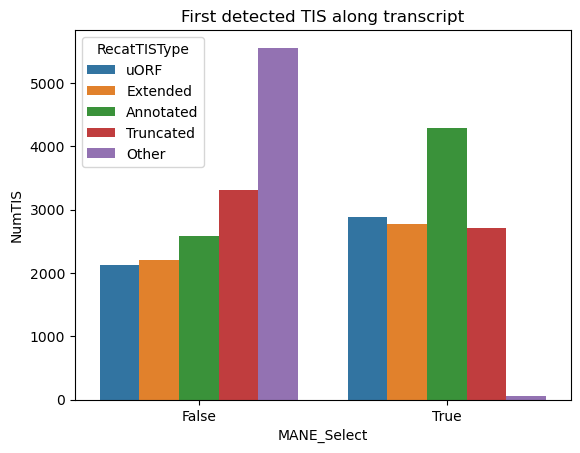

In [71]:
sns.barplot(
    all_replicate_tis_df[
        all_replicate_tis_df['TIS_ID'].isin(first_codon_tis_ids)
    ].drop_duplicates(subset=['TIS_ID']).value_counts(['MANE_Select', 'RecatTISType']).rename('NumTIS').reset_index(),
    x='MANE_Select', y='NumTIS', hue='RecatTISType', hue_order=tis_type_positional_order
)
plt.title('First detected TIS along transcript')

<Axes: xlabel='Sample', ylabel='SampleNormalizedTISCounts'>

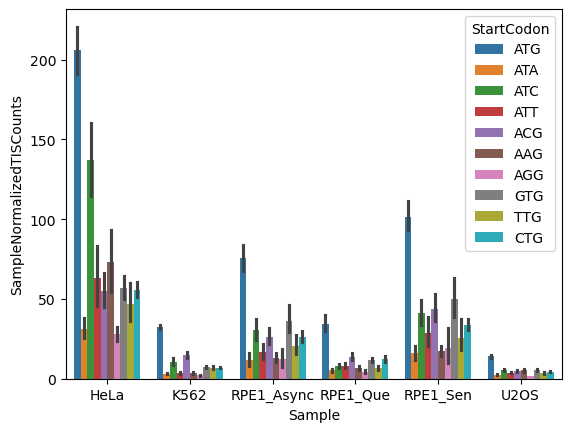

In [72]:
sns.barplot(
    all_replicate_tis_df[
        (~all_replicate_tis_df['Imputed']) &
        all_replicate_tis_df['TIS_ID'].isin(first_codon_tis_ids)
    ],
    x='Sample', y='SampleNormalizedTISCounts', hue='StartCodon', hue_order=codon_order
)

In [73]:
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

<Axes: xlabel='Sample', ylabel='LogTE'>

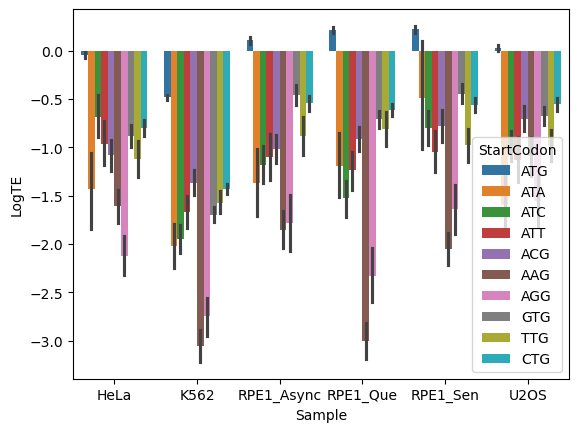

In [82]:
sns.barplot(
    all_replicate_tis_df[
        (~all_replicate_tis_df['Imputed']) &
        all_replicate_tis_df['TIS_ID'].isin(first_codon_tis_ids)
    ].merge(masked_te_matrix.melt(
        var_name='Sample', value_name='LogTE', ignore_index=False).reset_index(), left_on=['Sample', 'TIS'], right_on=['Sample', 'TIS']
    ).groupby(['Sample', 'TIS']).first().reset_index(),
    x='Sample', y='LogTE', hue='StartCodon', hue_order=codon_order
)

# Leaky scanning model 1:

We propose that the strength of translation at the canonical site is dependent on the length of the 5'UTR, the number of upstream alternative TISs (including uORFs), the identity of the start codons at the upstream aTISs, and the Kozak sequence similarity at the canonical site. The effects of each of these factors may be stronger or weaker in different cell lines.

This supposes the following model:

riboseq_counts ~ B0 + B1 * Kozak + B2 * N_upstream + B3 * N_AUG_alt + B4 * N_AUC_alt + ... + B(10?) * canonical_UTR_length + B11 * min_uORF_UTR_length + B12 * sample + B13 * sample:features...

## Step 1: Create a reference set of TIS sequences common to all samples (same reference genome)

In [ ]:
vst_log_te_matrix = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/translation_efficiency_vst_matrix.csv', index_col=0)
riboseq_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rpf_summed_replicate_counts.csv', index_col=0)
tis_mask = riboseq_counts >= 5
rna_counts = pd.read_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/rna_summed_replicate_counts.csv', index_col=0)
rna_mask = rna_counts >= 5
masked_te_matrix = vst_log_te_matrix[tis_mask & rna_mask].dropna(how='all')

In [ ]:
tis_with_sufficient_support_in_any_line = masked_te_matrix.index.tolist()

In [100]:
def define_global_tis_reference(longform_tis_table, masked_logte_matrix, sample_subset=None):
    if sample_subset is None: 
        sample_subset = masked_logte_matrix.columns.tolist()
    tis_with_sufficient_support = masked_logte_matrix[sample_subset].dropna(how='all').index.tolist() # TE defined in any line
    filtered_longform_tis_table = longform_tis_table[
        longform_tis_table['Sample'].isin(sample_subset) & 
        longform_tis_table['TIS'].isin(tis_with_sufficient_support)
    ].copy()
    filtered_longform_tis_table['GenomeStart'] = filtered_longform_tis_table['TIS'].str.split('_').str[-1]
    filtered_longform_tis_table['ChromosomePosition'] = filtered_longform_tis_table['GenomeStart'].str.split(':').str[1].astype(int)
    filtered_longform_tis_table['Orientation'] = filtered_longform_tis_table['GenomeStart'].str.split(':').str[-1]

    transcript_to_tis_vector_information = []
    tis_groups = filtered_longform_tis_table.groupby('Tid').groups
    for tid, tid_idxs in tqdm(tis_groups.items()):
        tid_subset = filtered_longform_tis_table.loc[tid_idxs, :]
        if tid_subset.iloc[0].loc['Orientation'] == '+': # forward, use an ascending sort on the chromosome position
            sort_ascending = True
        else:
            sort_ascending = False
        tid_subset_ordered = tid_subset.sort_values('ChromosomePosition', ascending=sort_ascending)
        ordered_unique_tis_subset = tid_subset_ordered.drop_duplicates(subset=['GenomeStart'])
        codon_string = '|'.join([s for s in ordered_unique_tis_subset['StartCodon'].tolist()])
        utr_length_string = '|'.join([str(int(s)) for s in ordered_unique_tis_subset['Start'].tolist()])
        tistype_string = '|'.join([s for s in ordered_unique_tis_subset['RecatTISType'].tolist()])
        transcript_to_tis_vector_information.append([tid, utr_length_string, codon_string, tistype_string])
    transcript_to_tis_vector_information = pd.DataFrame(transcript_to_tis_vector_information, columns=['Tid', 'UTRLengths', 'StartCodons', 'TISTypes'])
    return transcript_to_tis_vector_information


In [ ]:
global_tis_reference = define_global_tis_reference(all_replicate_tis_df, masked_te_matrix)
global_tis_reference.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_annotations.csv', index=False)

100%|██████████| 43123/43123 [02:13<00:00, 323.42it/s]


In [124]:
from Bio import SeqIO

def read_trancript_sequences(transcript_fasta='/lab/barcheese01/smaffa/coTISja/data/reference/gencode.v49.pc_transcripts.fa'):
    gencode_transcript_sequences = dict()
    for record in SeqIO.parse(transcript_fasta, format='fasta'):
        sequence_ids = record.id
        transcript_id = [tag for tag in sequence_ids.split('|') if 'ENST' in tag][0]
        gencode_transcript_sequences[transcript_id] = str(record.seq)
    gencode_transcript_sequences = pd.DataFrame(pd.Series(gencode_transcript_sequences), columns=['Seq']).reset_index(names=['Tid'])
    gencode_transcript_sequences['Len'] = gencode_transcript_sequences['Seq'].apply(lambda x: len(x))
    return gencode_transcript_sequences

# Define IUPAC ambiguity codes
ambiguity_dict = {
    'A': {'A'}, 'C': {'C'}, 'G': {'G'}, 'T': {'T'}, 'U': {'T'},
    'R': {'A', 'G'}, 'Y': {'C', 'T'}, 'M': {'A', 'C'},
    'K': {'G', 'T'}, 'S': {'C', 'G'}, 'W': {'A', 'T'},
    'B': {'C', 'G', 'T'}, 'D': {'A', 'G', 'T'}, 'H': {'A', 'C', 'T'},
    'V': {'A', 'C', 'G'}, 'N': {'A', 'C', 'G', 'T'},
    'a': {'A'}, 'c': {'C'}, 'g': {'G'}, 't': {'T'}, 'u': {'T'}
}

kozak_pattern = 'gccgccRccATGG'
partial_weights = [0.1,0.1,0.1,0.1,0.1,0.1,1,0.1,0.1,1,1,1,1]
major_weights = [0,0,0,0,0,0,1,0,0,1,1,1,1]

def hamming_distance_ambiguous(s1, s2, weights=None):
    """Calculate Hamming distance between two sequences with ambiguous bases."""
    if len(s1) != len(s2):
        raise ValueError("Sequences must be of equal length")
    
    if weights is None:
        weights = [1] * len(s1)

    distance = 0
    position_i = 0
    for a, b in zip(s1, s2):
        set_a = ambiguity_dict.get(a, {a})
        set_b = ambiguity_dict.get(b, {b})
        if not set_a.intersection(set_b):  # No overlap → mismatch
            distance += weights[position_i]
        position_i += 1
    return distance

In [ ]:
reference_transcript_sequences = read_trancript_sequences()

In [125]:
def assign_canonical_kozak_annotations(tis_vector_annotations, transcript_sequences):
    annotated_tis_vector_metadata = tis_vector_annotations.merge(transcript_sequences, left_on='Tid', right_on='Tid', how='left')

    canonical_subset = annotated_tis_vector_metadata[
        annotated_tis_vector_metadata['TISTypes'].str.contains('Annotated')
    ].copy()
    canonical_subset['CanonicalIndex'] = canonical_subset['TISTypes'].apply(lambda x: x.split('|').index('Annotated'))
    canonical_subset['CanonicalStart'] = canonical_subset.apply(lambda x: int(x['UTRLengths'].split('|')[int(x['CanonicalIndex'])]), axis=1)
    canonical_subset['CanonicalKozakContext'] = canonical_subset.apply(
        lambda x: x['Seq'][(int(x['CanonicalStart']) - 9):(int(x['CanonicalStart']) + 4)], axis=1
    )

    annotated_tis_vector_metadata = annotated_tis_vector_metadata.merge(canonical_subset, how='left')

    hamming_subset = annotated_tis_vector_metadata[
        annotated_tis_vector_metadata['CanonicalKozakContext'].apply(lambda x: len(x) == 13 if isinstance(x, str) else False)
    ].copy()
    hamming_subset['KozakHammingDistance'] = hamming_subset.apply(
        lambda x: hamming_distance_ambiguous(kozak_pattern, x['CanonicalKozakContext'], weights=None), axis=1
    )
    hamming_subset['KozakMajorHammingDistance'] = hamming_subset.apply(
        lambda x: hamming_distance_ambiguous(kozak_pattern, x['CanonicalKozakContext'], weights=major_weights), axis=1
    )

    annotated_tis_vector_metadata = annotated_tis_vector_metadata.merge(hamming_subset, how='left')
    return annotated_tis_vector_metadata


In [130]:
global_tis_reference_df = assign_canonical_kozak_annotations(global_tis_reference, reference_transcript_sequences)
global_tis_reference_df.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/transcript_tis_vector_annotations.csv', index=False)

## Step 2: Featurize the replicate data

In [163]:
def featurize_by_canonical_sites(tid_summary_metadata, tis_df, 
                                 sample_id_columns=['Sample', 'Replicate'], 
                                 response_variable_columns=['TISCounts', 'GeneRNASeqCounts', 'GeneRNASeqLogRPM'], 
                                 extra_transcript_columns=['MANE_Select']):
    
    # extract features from the annotation metadata summary
    canonical_subset = tid_summary_metadata[
        tid_summary_metadata['TISTypes'].str.contains('Annotated')
    ].dropna()

    predictors_table = pd.concat([
        canonical_subset['Tid'],
        canonical_subset.apply(lambda x: len(x['StartCodons'].split('|')[:int(x['CanonicalIndex'])]), axis=1).rename('NumUpstreamTIS'),
    ] + [
        canonical_subset.apply(lambda x: len([y for y in x['StartCodons'].split('|')[:int(x['CanonicalIndex'])] if y == codon]), axis=1).rename(f'NumUpstream{codon}') for codon in codon_order
    ] + [
        canonical_subset.apply(lambda x: len([y for y in x['StartCodons'].split('|')[:int(x['CanonicalIndex'])] if y == tistype]), axis=1).rename(f'NumUpstream{tistype}') for tistype in ['uORF', 'Extension', 'Other']
    ] + [
        canonical_subset['UTRLengths'].apply(lambda x: int(x.split('|')[0])).rename('FirstUTRLength'),
        canonical_subset.apply(lambda x: int(x['UTRLengths'].split('|')[int(x['CanonicalIndex'])]), axis=1).rename('CanonicalUTRLength'),
        canonical_subset['KozakHammingDistance'],
        canonical_subset['KozakMajorHammingDistance']
    ], axis=1)

    # extract observations from the longform tis df
    observations_table = tis_df[
        tis_df['Tid'].isin(canonical_subset['Tid']) &
        (tis_df['RecatTISType'] == 'Annotated')
    ][['Tid'] + sample_id_columns + response_variable_columns + extra_transcript_columns]

    feature_table = observations_table.merge(predictors_table, left_on='Tid', right_on='Tid', how='outer')
    return feature_table

In [164]:
feature_table = featurize_by_canonical_sites(tid_summary_metadata=global_tis_reference_df, tis_df=all_replicate_tis_df)

In [165]:
feature_table.to_csv('/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/glm_model_inputs.csv', index=False)

## Step 3: Fit the GLM

In [170]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="""
    TISCounts ~ 
        KozakHammingDistance +
        NumUpstreamATG +
        NumUpstreamNonATG +
        CanonicalUTRLength +
        Sample +
        KozakHammingDistance:Sample +
        NumUpstreamATG:Sample +
        NumUpstreamNonATG:Sample +
        CanonicalUTRLength:Sample
    """,
    data=feature_table.assign(
        NumUpstreamNonATG=lambda x: x['NumUpstreamTIS'] - x['NumUpstreamATG']
    ),
    family=sm.families.NegativeBinomial(),
    offset=feature_table["GeneRNASeqLogRPM"]
).fit()

print(model.summary())

/lab/barcheese01/smaffa/miniforge3/envs/riboseq/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:              TISCounts   No. Observations:               138190
Model:                            GLM   Df Residuals:                   138160
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0116e+06
Date:                Wed, 18 Mar 2026   Deviance:                   1.0216e+06
Time:                        18:14:05   Pearson chi2:                 4.09e+08
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8144
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

In [193]:
def write_glm_results(model, filename):
    with open(filename, "w") as f:
        f.write(model.summary().as_csv())

In [194]:
write_glm_results(model, '/lab/barcheese01/smaffa/coTISja/data/tisdiff_results/deseq2/global/canonical_translation_glm_model_fit.csv')

## Step 4: Extract relevant coefficients for interpretation & F tests for predictor relevance

## Step 5: Compare to Random Forest

,Sample,Replicate,Gid,Tid,Symbol,GeneType,GenomePos,GenomeStart,Start,StartCodon,TisType,RecatTISType,TISGroup,TISCounts,NormTISCounts,GeneRNASeqCounts,TotalRNASeqCounts,AALen,MANE_Select,transcript_support_level,Imputed,AASeq,IsoformID,TIS_ID,TIS,SampleScaleFactor,GeneRNASeqRPM,GeneRNASeqLogRPM,GeneAbundanceScaleFactor,SampleNormalizedTISCounts,GeneNormalizedTISCounts,FullNormalizedTISCounts
0,HeLa,rep1,ENSG00000188976.12,ENST00000327044.7,NOC2L,protein_coding,chr1:944693-959240:-,chr1:959240,16.0,ATG,Annotated,Annotated,3,14,4.658826,565.0,3005049,749.0,True,1.0,False,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...,ENST00000327044.7:16,ENSG00000188976.12:chr1:959240,ENST00000327044.7_16_chr1:959240:-,1.000000,188.349674,7.557270,0.803972,14.0,11.255606,11.255606
1,HeLa,rep1,ENSG00000188976.12,ENST00000487214.1,NOC2L,protein_coding,chr1:954456-959240:-,chr1:959240,69.0,ATG,Novel:Known,Other,4,14,4.658826,565.0,3005049,254.0,False,3.0,False,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...,ENST00000487214.1:69,ENSG00000188976.12:chr1:959240,ENST00000487214.1_69_chr1:959240:-,1.000000,188.349674,7.557270,0.803972,14.0,11.255606,11.255606
2,HeLa,rep1,ENSG00000188976.12,ENST00000487214.1,NOC2L,protein_coding,chr1:954456-959219:-,chr1:959219,90.0,AAG,Novel:CDSFrameOverlap,Other,4,50,16.638664,565.0,3005049,247.0,False,3.0,False,KRRLAELTVDEFLASGFDSESESESENSPQAETREAREAARSPDKP...,ENST00000487214.1:90,ENSG00000188976.12:chr1:959219,ENST00000487214.1_90_chr1:959219:-,1.000000,188.349674,7.557270,0.803972,50.0,40.198594,40.198594
3,HeLa,rep1,ENSG00000187608.11,ENST00000624697.4,ISG15,protein_coding,chr1:1013998-1014478:+,chr1:1013998,245.0,GTG,Extended:CDSFrameOverlap,Extended,1,10,3.327733,72.0,3005049,159.0,False,3.0,False,VKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLAVHPSGV...,ENST00000624697.4:245,ENSG00000187608.11:chr1:1013998,ENST00000624697.4_245_chr1:1013998:+,1.000000,24.292449,4.602436,1.320134,10.0,13.201340,13.201340
4,HeLa,rep1,ENSG00000187608.11,ENST00000649529.1,ISG15,protein_coding,chr1:1013546-1014478:+,chr1:1013546,50.0,GTG,Extended,Extended,3,45,14.974797,72.0,3005049,174.0,True,NaN,False,VAHSPQPTAMGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIG...,ENST00000649529.1:50,ENSG00000187608.11:chr1:1013546,ENST00000649529.1_50_chr1:1013546:+,1.000000,24.292449,4.602436,1.320134,45.0,59.406030,59.406030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430121,U2OS,rep2,ENSG00000130826.20,ENST00000369550.10,DKC1,protein_coding,chrX:154762966-154776864:+,chrX:154762966,102.0,ATG,Annotated,Annotated,0,0,0.000000,3522.0,13731484,514.0,True,1.0,True,MADAEVIILPKKHKKKKERKSLPEEDVAEIQHAEEFLIKPESKVAK...,ENST00000369550.10:102,ENSG00000130826.20:chrX:154762966,ENST00000369550.10_102_chrX:154762966:+,0.218844,256.563675,8.003173,0.759178,0.0,0.000000,0.000000
430122,U2OS,rep2,ENSG00000182712.16,ENST00000369479.1,CMC4,protein_coding,chrX:155061846-155064023:-,chrX:155064023,442.0,ATG,Annotated,Annotated,0,0,0.000000,140.0,13731484,68.0,False,3.0,True,MPQKDPCQKQACEIQKCLQANSYMESKCQAVIQELRKCCAQYPKGR...,ENST00000369479.1:442,ENSG00000182712.16:chrX:155064023,ENST00000369479.1_442_chrX:155064023:-,0.218844,10.268373,3.360136,1.808210,0.0,0.000000,0.000000
430123,U2OS,rep2,ENSG00000185515.16,ENST00000369462.5,BRCC3,protein_coding,chrX:155071528-155120147:+,chrX:155071528,25.0,ATG,Annotated,Annotated,0,0,0.000000,354.0,13731484,316.0,False,1.0,True,MAVQVVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDT...,ENST00000369462.5:25,ENSG00000185515.16:chrX:155071528,ENST00000369462.5_25_chrX:155071528:+,0.218844,25.852996,4.692260,1.294863,0.0,0.000000,0.000000
430124,U2OS,rep2,ENSG00000185515.16,ENST00000330045.12,BRCC3,protein_coding,chrX:155071528-155120147:+,chrX:155071528,20.0,ATG,Annotated,Annotated,0,0,0.000000,354.0,13731484,291.0,True,1.0,True,MAVQVVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDT...,ENST00000330045.12:20,ENSG00000185515.16:chrX:155071528,ENST00000330045.12_20_chrX:155071528

In [ ]:
all_replicate_tis_df.sort_values()

,Sample,Replicate,Gid,Tid,Symbol,GeneType,GenomePos,GenomeStart,Start,StartCodon,TisType,RecatTISType,TISGroup,TISCounts,NormTISCounts,GeneRNASeqCounts,TotalRNASeqCounts,AALen,MANE_Select,transcript_support_level,Imputed,AASeq
0,HeLa,rep1,ENSG00000188976.12,ENST00000327044.7,NOC2L,protein_coding,chr1:944693-959240:-,chr1:959240,16.0,ATG,Annotated,Annotated,3,14,4.658826,565.0,3005049,749.0,True,1.0,False,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...
1,HeLa,rep1,ENSG00000188976.12,ENST00000487214.1,NOC2L,protein_coding,chr1:954456-959240:-,chr1:959240,69.0,ATG,Novel:Known,Other,4,14,4.658826,565.0,3005049,254.0,False,3.0,False,MAAAGSRKRRLAELTVDEFLASGFDSESESESENSPQAETREAREA...
2,HeLa,rep1,ENSG00000188976.12,ENST00000487214.1,NOC2L,protein_coding,chr1:954456-959219:-,chr1:959219,90.0,AAG,Novel:CDSFrameOverlap,Other,4,50,16.638664,565.0,3005049,247.0,False,3.0,False,KRRLAELTVDEFLASGFDSESESESENSPQAETREAREAARSPDKP...
3,HeLa,rep1,ENSG00000187608.11,ENST00000624697.4,ISG15,protein_coding,chr1:1013998-1014478:+,chr1:1013998,245.0,GTG,Extended:CDSFrameOverlap,Extended,1,10,3.327733,72.0,3005049,159.0,False,3.0,False,VKMLAGNEFQVSLSSSMSVSELKAQITQKIGVHAFQQRLAVHPSGV...
4,HeLa,rep1,ENSG00000187608.11,ENST00000649529.1,ISG15,protein_coding,chr1:1013546-1014478:+,chr1:1013546,50.0,GTG,Extended,Extended,3,45,14.974797,72.0,3005049,174.0,True,NaN,False,VAHSPQPTAMGWDLTVKMLAGNEFQVSLSSSMSVSELKAQITQKIG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430121,U2OS,rep2,ENSG00000130826.20,ENST00000369550.10,DKC1,protein_coding,chrX:154762966-154776864:+,chrX:154762966,102.0,ATG,Annotated,Annotated,0,0,0.000000,3522.0,13731484,514.0,True,1.0,True,MADAEVIILPKKHKKKKERKSLPEEDVAEIQHAEEFLIKPESKVAK...
430122,U2OS,rep2,ENSG00000182712.16,ENST00000369479.1,CMC4,protein_coding,chrX:155061846-155064023:-,chrX:155064023,442.0,ATG,Annotated,Annotated,0,0,0.000000,140.0,13731484,68.0,False,3.0,True,MPQKDPCQKQACEIQKCLQANSYMESKCQAVIQELRKCCAQYPKGR...
430123,U2OS,rep2,ENSG00000185515.16,ENST00000369462.5,BRCC3,protein_coding,chrX:155071528-155120147:+,chrX:155071528,25.0,ATG,Annotated,Annotated,0,0,0.000000,354.0,13731484,316.0,False,1.0,True,MAVQVVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDT...
430124,U2OS,rep2,ENSG00000185515.16,ENST00000330045.12,BRCC3,protein_coding,chrX:155071528-155120147:+,chrX:155071528,20.0,ATG,Annotated,Annotated,0,0,0.000000,354.0,13731484,291.0,True,1.0,True,MAVQVVQAVQAVHLESDAFLVCLNHALSTEKEEVMGLCIGELNDDT...
